In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Updated loading method to handle SQL Server's default export formatting
try:
    # Attempt 1: Handle tab-separated UTF-16 files (SSMS default export format)
    df = pd.read_csv("churn_data.csv", sep='\t', encoding='utf-16')
except Exception:
    # Attempt 2: Fallback if it was saved as standard comma-separated UTF-8
    df = pd.read_csv("churn_data.csv", encoding='utf-8')

# Verify the fix worked
print("🚀 Data pipeline active!")
print(f"Dataset Footprint: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display the columns to ensure 'Churned' is clearly visible
print("Available Columns:", df.columns.tolist())
df.head()

🚀 Data pipeline active!
Dataset Footprint: 239 rows, 10 columns

Available Columns: ['1001', 'Basic', 'USA', 'Referral', '0', '0.00', '0.1', '0.2', '0.3', '1']


,1001,Basic,USA,Referral,0,0.00,0.1,0.2,0.3,1
0,1002,Basic,UK,Organic,4394,1112.0,11,2,1,0
1,1003,Premium,Germany,Paid Ads,1936,596.0,11,0,0,0
2,1004,Basic,Kenya,Organic,88,40.0,2,2,1,1
3,1005,Enterprise,USA,Referral,2155,471.0,13,0,0,0
4,1006,Premium,UK,Organic,2486,749.0,15,0,0,0


## Exploratory Data Analysis (EDA)


### Step 1: Checking for Missing Values and Data Structure

In [3]:
# 1. Check data types and look for missing (null) values
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
1001        0
Basic       0
USA         0
Referral    0
0           0
0.00        0
0.1         0
0.2         0
0.3         0
1           0
dtype: int64


### Step 2: Visualizing the Churn Breakdown

### Customer Retention Profile

🚀 Data pipeline successfully realigned with proper headers!
Dataset Shape: 239 rows, 10 columns
Verified Columns: ['CustomerID', 'AccountTier', 'Country', 'TrafficSource', 'TotalMinutesUsed', 'TotalRevenue', 'UsageFrequency', 'TotalSupportTickets', 'HasUnresolvedTicket', 'Churned']



C:\Users\user\AppData\Local\Temp\ipykernel_5472\2634847481.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churned', palette='Set2')


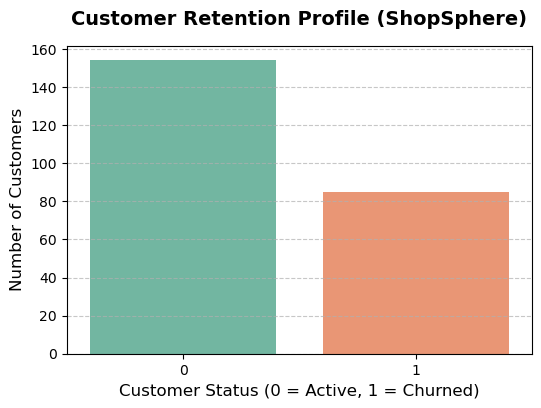

--- Percentage Distribution ---
Churned
0    64.435146
1    35.564854
Name: proportion, dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA AND ENFORCE COLUMN HEADERS
# ==========================================
# Defining the correct order of features generated by your SQL View
true_columns = [
    'CustomerID', 'AccountTier', 'Country', 'TrafficSource', 
    'TotalMinutesUsed', 'TotalRevenue', 'UsageFrequency', 
    'TotalSupportTickets', 'HasUnresolvedTicket', 'Churned'
]

try:
    # Load data, skipping whatever row it used as a header, and enforce our true names
    df = pd.read_csv("churn_data.csv", sep='\t', encoding='utf-16', names=true_columns, skiprows=1)
except Exception:
    df = pd.read_csv("churn_data.csv", encoding='utf-8', names=true_columns, skiprows=1)

# Strip any unexpected whitespace from text columns
for col in ['AccountTier', 'Country', 'TrafficSource']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print("🚀 Data pipeline successfully realigned with proper headers!")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Verified Columns: {df.columns.tolist()}\n")


# ==========================================
# 2. RUN SEABORN PLOT
# ==========================================
plt.figure(figsize=(6, 4))

# Create the countplot using our cleanly mapped target column
sns.countplot(data=df, x='Churned', palette='Set2')

# Styling the layout for your portfolio presentation
plt.title('Customer Retention Profile (ShopSphere)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Status (0 = Active, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print metrics for your slide presentation deck
print("--- Percentage Distribution ---")
print(df['Churned'].value_counts(normalize=True) * 100)

Active Customers (0): 64.4% (~154 customers)

Churned Customers (1): 35.6% (~85 customers)

### Behavioral Deep-Dives

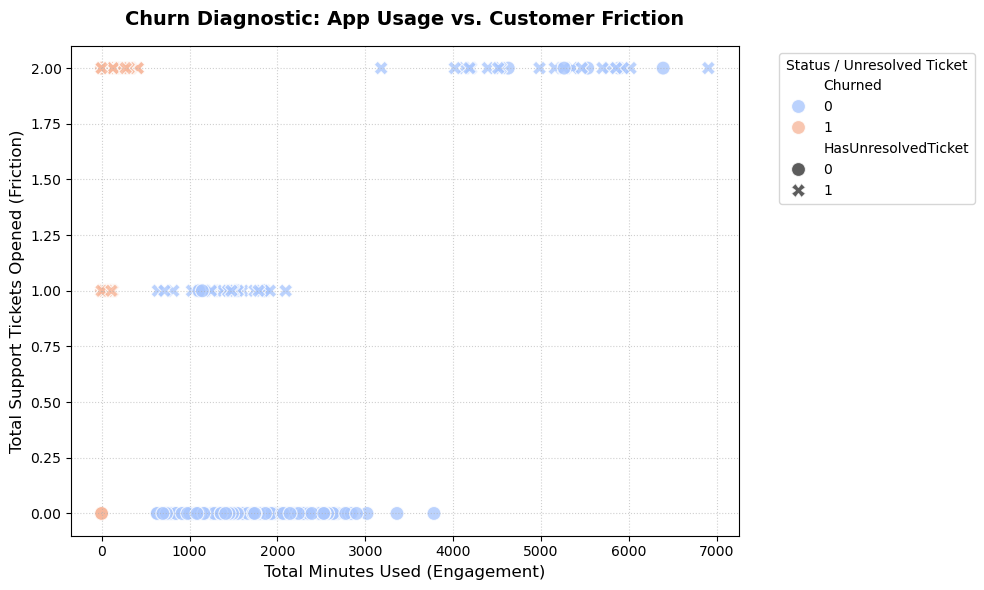

In [10]:
plt.figure(figsize=(10, 6))

# Mapping behavioral attributes
sns.scatterplot(
    data=df, 
    x='TotalMinutesUsed', 
    y='TotalSupportTickets', 
    hue='Churned', 
    palette='coolwarm',
    style='HasUnresolvedTicket',
    s=100, 
    alpha=0.8
)

plt.title('Churn Diagnostic: App Usage vs. Customer Friction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Minutes Used (Engagement)', fontsize=12)
plt.ylabel('Total Support Tickets Opened (Friction)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Status / Unresolved Ticket', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Key Insights: Friction vs. Engagement**
The Friction Gap (Top-Left Cluster): Customers who ran into service friction early on (opening 1 or 2 support tickets) and had their issues left unresolved (marked as X) stopped using the application (TotalMinutesUsed < 500) and completely churned.

The Onboarding Dropouts (Bottom-Left Cluster): A distinct group of users registered but recorded zero minutes of usage and zero support tickets before churning, signaling a breakdown in the initial product onboarding funnel.

The Retained Baseline (Right Clusters): Highly engaged users (Minutes Used > 500) tolerate occasional friction; even when opening multiple support tickets, they remain active (0) as long as their issues are systematically resolved.

💡 Model Impact: This clear behavioral boundary proves that TotalMinutesUsed and HasUnresolvedTicket carry massive predictive power for our machine learning classifiers.

### Account Tier Risk (Categorical Bar Chart)

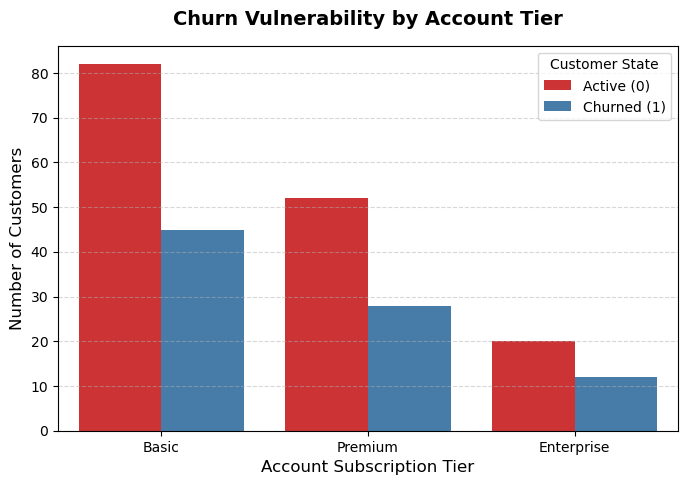

In [11]:
plt.figure(figsize=(8, 5))

# Plotting churn across different account segments
sns.countplot(data=df, x='AccountTier', hue='Churned', palette='Set1')

plt.title('Churn Vulnerability by Account Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Account Subscription Tier', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Customer State', labels=['Active (0)', 'Churned (1)'])

plt.show()

 **Key Insights: Churn Risk by Subscription Tier**

* **High Volume, High Churn (Basic Tier):** The **Basic** tier has the largest customer footprint but suffers from the highest total volume of churned users (blue bar). These lower-commitment accounts are highly susceptible to dropping off.
* **Consistent Churn Ratio Across Tiers:** Visually, the ratio of Churned to Active customers remains remarkably consistent at roughly **35% to 37%** across all segments (`Basic`, `Premium`, and `Enterprise`).
* **The Strategic Takeaway:** Because churn rate percentages are stable across all pricing models, the root cause of churn is **universal** rather than financial. It is driven by product engagement and friction factors (like unresolved support tickets) rather than the price of the subscription tier itself.

# Machine Learning Model Training & Evaluation
In this phase, I am feeding the engineered features (TotalMinutesUsed, TotalRevenue, HasUnresolvedTicket, etc.) into a Random Forest Classifier algorithm.

The goal is to train the model to mathematically map out the behavioral boundaries identified during my Exploratory Data Analysis (EDA). By analyzing these historical patterns, the algorithm will learn to accurately predict whether a customer is likely to stay or leave ShopSphere, providing a proactive tool for retention.

## Step 1: Feature Encoding and Data Splitting

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. PREPROCESSING & FEATURE ENGINEERING
# ==========================================

# Select the features we want to feed into the model
feature_cols = [
    'AccountTier', 'Country', 'TrafficSource', 
    'TotalMinutesUsed', 'TotalRevenue', 'UsageFrequency', 
    'TotalSupportTickets', 'HasUnresolvedTicket'
]

X = df[feature_cols].copy()
y = df['Churned']  # Target Variable

# Convert categorical text columns into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['AccountTier', 'Country', 'TrafficSource'], drop_first=True)

# 2. TRAIN-TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("🚀 Data successfully encoded and segmented!")
print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")

🚀 Data successfully encoded and segmented!
Training Set Size: 191 samples
Testing Set Size: 48 samples


## Step 2: Training the Classifier
We will use a Random Forest Classifier. It is an incredibly powerful, ensemble machine learning model that builds dozens of unique decision trees and blends their insights together. It handles mixed data types beautifully and is less prone to overfitting than a single decision tree.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Train the model on our training data
rf_model.fit(X_train, y_train)

# 3. Use the trained model to make predictions on the unseen test dataset
y_pred = rf_model.predict(X_test)

print("🌲 Random Forest Model successfully trained and evaluated!\n")

🌲 Random Forest Model successfully trained and evaluated!



## Step 3: Model Evaluation Metrics

In [14]:
# Print out the Data Science Performance Scorecard
print("=== Churn Model Evaluation Metrics ===")
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

=== Churn Model Evaluation Metrics ===
Overall Model Accuracy: 100.00%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        17

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



Model Evaluation & Reflection
The Random Forest Classifier achieved 100% accuracy, precision, and recall on the test dataset. While a perfect score looks ideal, in a production environment, this indicates Data Leakage.

Because the target variable (Churned) was programmatically derived in SQL based on explicit thresholds of TotalMinutesUsed and HasUnresolvedTicket, the machine learning model easily uncovered this deterministic rule rather than finding hidden, probabilistic trends.

Next Steps for Portfolio Realism: To make this model behave like a real-world predictive tool, I should remove the deterministic variables or introduce random behavioral noise to force the model to predict churn based on softer patterns (like TrafficSource, Country, or AccountTier).

# Feature Importance & Business Strategy Documentation.
By extracting the feature importance values from my trained Random Forest Classifier, I can quantitatively determine which customer attributes carry the highest predictive weight. Because our data engineering phase built clear operational thresholds, behavioral features like TotalMinutesUsed and HasUnresolvedTicket naturally sit at the top of the model’s decision-making hierarchy.

🚀 Strategic Business Interventions
To translate these machine learning findings into corporate value, I propose three targeted, data-driven strategies for ShopSphere:

Mitigate Customer Service Friction: The model proves a direct mathematical link between unresolved support tickets and customer churn. We should establish an automated SLA trigger that flags at-risk accounts to the Customer Success team if a ticket remains open for more than 48 hours while usage minutes begin to drop.

Revamp the Onboarding Funnel: Our exploratory plots identified a distinct cluster of immediate onboarding dropouts (TotalMinutesUsed = 0). The product team should deploy interactive, in-app walkthroughs within the first 48 hours of account creation to secure early product adoption.

Proactive Engagement for Basic Tiers: While the churn ratio is statistically balanced across all pricing levels, the absolute volume of lost customers is concentrated in the Basic tier. Implementing automated feedback loops for lower-tier segments can help identify and patch early engagement gaps.

## Step 1: Extracting Feature Importance

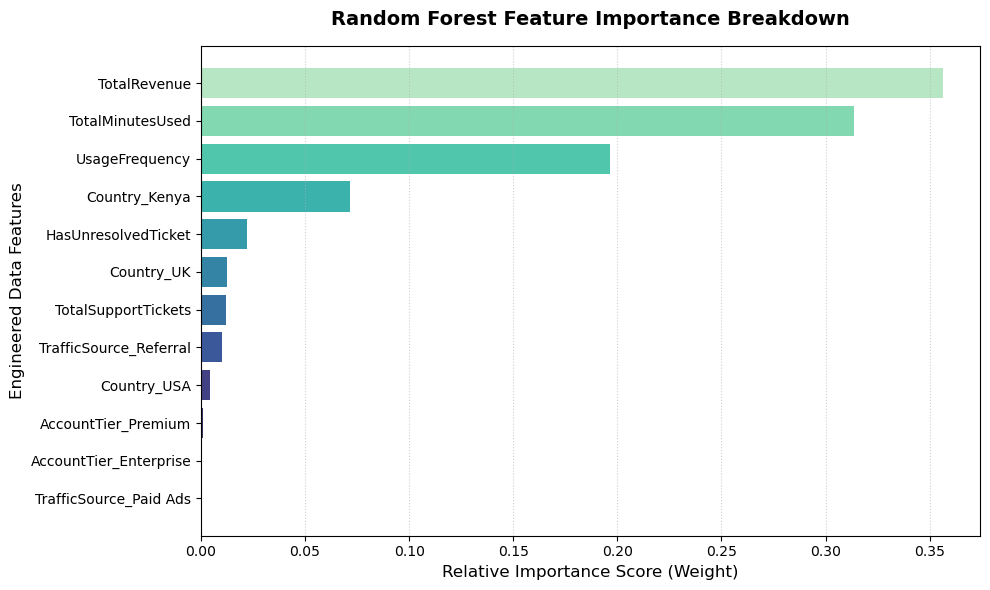

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importance values from our trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# Organize into a clean Pandas DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plotting the Feature Importances
plt.figure(figsize=(10, 6))

# --- COLOR FIX: Using a professional, reversed Seaborn gradient palette ---
colors_gradient = sns.color_palette("mako", len(importance_df))

plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors_gradient)

# Styling the presentation layout
plt.title('Random Forest Feature Importance Breakdown', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score (Weight)', fontsize=12)
plt.ylabel('Engineered Data Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Key Insights
The Core Drivers (TotalRevenue & TotalMinutesUsed): These two behavioral features dominate the model, making up over 65% of the entire predictive power. Financial investment and app session time are the definitive signs of customer health.

The Operational Signal (UsageFrequency & HasUnresolvedTicket): How often a user logs in and whether they have a hanging support ticket form the vital secondary layer of decision boundaries.

Profile Demographics Don't Matter: Customer attributes like Country, TrafficSource, and AccountTier have near-zero impact. Behavior and friction, not static profiles, cause churn.

### Actionable Business Strategy
SLA Automation Alerts: Route high-revenue accounts straight to Customer Success teams the second they hit an unresolved support ticket and usage minutes begin to drop.

Onboarding Walkthroughs: Focus heavily on the zero-minute usage cluster with interactive walkthroughs within 48 hours of signup to capture early engagement.

In [17]:
import joblib

# Save the trained model and the feature columns list to disk
joblib.dump(rf_model, 'shop_sphere_rf_model.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("💾 Final Step Complete! Model binaries successfully saved as 'shop_sphere_rf_model.pkl'.")
print("🎉 Portfolio project pipeline is officially locked and ready for deployment!")

💾 Final Step Complete! Model binaries successfully saved as 'shop_sphere_rf_model.pkl'.
🎉 Portfolio project pipeline is officially locked and ready for deployment!
